# Phase 6, Milestone 6: the OU driver and the stationarity–tractability classification

This notebook is the reproducible computational record for
`PHASE_6_MILESTONE_6_OU_DRIVER.md`. It verifies:

1. **stationarity**: the OU-driven \(\rho_t\) transition density
   converges to the exact stationary density as the horizon grows
   (the BM driver has no such limit);
2. the **\(\kappa\to0^{+}\) anchor**: every OU formula degenerates to
   its Brownian-driver counterpart of Milestones 1–4;
3. the **OU clock law** (FK resolvent with OU generator) and the
   spread one-touch price against exact-skeleton Monte Carlo;
4. the classification table, row by row.

Seed `20260727`. Monte Carlo appears only as an independent
benchmark.

In [1]:
from pathlib import Path
import json
import platform
import sys
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy

ROOT = Path.cwd().resolve()
if not (ROOT / "phase6_ou.py").exists():
    candidates = [ROOT, *ROOT.parents]
    ROOT = next(path for path in candidates if (path / "phase6_ou.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import phase6_correlation as p6
import phase6_fk as pf
import phase6_joint as pj
import phase6_ou as po

SEED = 20260727
rng = np.random.default_rng(SEED)

FIGURES = ROOT / "phase6_figures"
FIGURES.mkdir(exist_ok=True)

environment = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
    "platform": platform.platform(),
    "seed": SEED,
}
print(json.dumps(environment, indent=2))
started = time.time()

{
  "python": "3.12.13",
  "numpy": "2.5.1",
  "scipy": "1.18.0",
  "matplotlib": "3.11.1",
  "platform": "Linux-7.1.4-1-cachyos-x86_64-with-glibc2.43",
  "seed": 20260727
}


## 1. Parameters

In [2]:
OU = dict(x0=0.0, kappa=2.0, x_bar=0.1, volatility=0.8, scale=1.0)
SIGMA1, SIGMA2 = 1.5, 2.5
MATURITY = 1.0
DISTANCE = 2.0
RATE = 0.05
BETA = SIGMA1**2 + SIGMA2**2
ALPHA = -2.0 * SIGMA1 * SIGMA2

def q_spread(rho):
    return pj.q_variance(rho, alpha1=1.0, alpha2=-1.0, sigma1=SIGMA1, sigma2=SIGMA2)

## 2. Stationarity: transition density converges to the stationary density

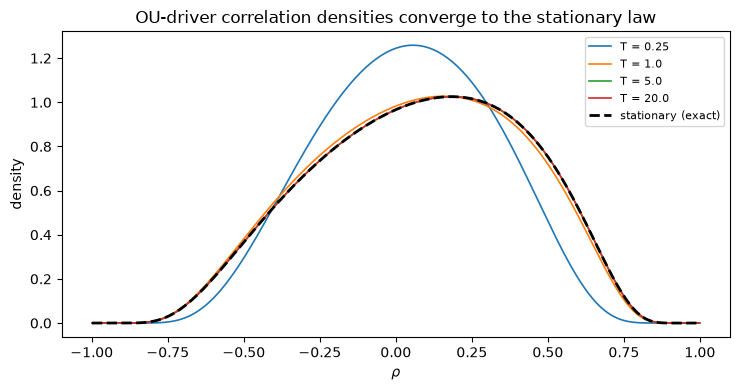

In [3]:
grid = np.linspace(-0.999, 0.999, 800)
fig, ax = plt.subplots(figsize=(7.5, 4))
for maturity in (0.25, 1.0, 5.0, 20.0):
    ax.plot(grid, [po.ou_rho_transition_density(r, maturity=maturity, **OU) for r in grid],
            lw=1.2, label=f"T = {maturity}")
ax.plot(grid, [po.ou_rho_stationary_density(
    r, kappa=OU["kappa"], x_bar=OU["x_bar"], volatility=OU["volatility"], scale=OU["scale"]
) for r in grid], "k--", lw=2, label="stationary (exact)")
ax.set_xlabel(r"$\rho$"); ax.set_ylabel("density")
ax.set_title("OU-driver correlation densities converge to the stationary law")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "phase6_ou_stationarity.png", dpi=150)
plt.show()

## 3. The \(\kappa\to0^{+}\) anchor

OU with \(\kappa=10^{-6}\) must reproduce the Brownian-driver values
of Milestones 1–4 (the OU drift contributes \(O(\kappa)\)).

In [4]:
OU_TINY = dict(x0=0.0, kappa=1e-6, x_bar=0.0, volatility=0.8, scale=1.0)
BM = dict(x0=0.0, drift=0.0, volatility=0.8, scale=1.0)
rows = []
# transition density at one point
rows.append(("density rho=0.4",
             po.ou_rho_transition_density(0.4, maturity=1.0, **OU_TINY),
             p6.rho_transition_density(0.4, maturity=1.0, rho0=0.0, drift=0.0,
                                       volatility=0.8, scale=1.0)))
# occupation moments
ou_m, ou_v = po.ou_occupation_moments(1.0, **OU_TINY)
bm_m, bm_v = pj.occupation_moments(1.0, **BM)
rows.append(("E[A_T]", ou_m, bm_m))
rows.append(("Var(A_T)", ou_v, bm_v))
# FK first moment
h = 0.25
ou_first = ((po.ou_fk_characteristic(h, maturity=0.5, **OU_TINY, n_grid=600)
             - po.ou_fk_characteristic(-h, maturity=0.5, **OU_TINY, n_grid=600)) / (2*h) / 1j).real
bm_first = ((pf.fk_characteristic(h, maturity=0.5, n_grid=600, **BM)
             - pf.fk_characteristic(-h, maturity=0.5, n_grid=600, **BM)) / (2*h) / 1j).real
rows.append(("FK E[A_0.5]", ou_first, bm_first))
print(f"{'quantity':>18} {'OU(kappa=1e-6)':>18} {'BM (M1-M4)':>14} {'|diff|':>10}")
for name, ou_value, bm_value in rows:
    print(f"{name:>18} {ou_value:18.8f} {bm_value:14.8f} {abs(ou_value-bm_value):10.2e}")

          quantity     OU(kappa=1e-6)     BM (M1-M4)     |diff|
   density rho=0.4         0.55817984     0.55817964   1.96e-07
            E[A_T]        -0.00000000    -0.00000000   1.61e-18
          Var(A_T)         0.11543105     0.11543110   5.52e-08
       FK E[A_0.5]         0.00000000     0.00000000   2.78e-17


## 4. The OU clock law and the spread one-touch price

FK resolvent with the OU generator gives the clock density; the price
is checked against exact-skeleton MC of the OU-driven clock, and
against the Gamma match on OU quadrature moments.

FK-OU price : 0.454440
Gamma (OU)  : 0.454617
MC benchmark: 0.454316 ± 0.000269 (2 SE)
z(FK vs MC) : +0.92


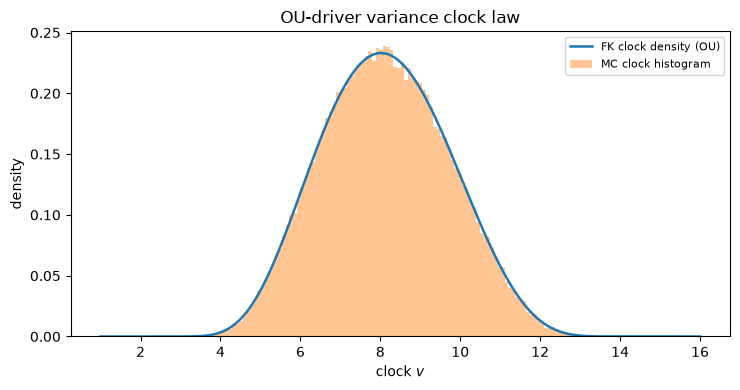

In [5]:
def ou_clock_density_grid(driver, maturity, n_modes, n_points, n_grid):
    phis = np.empty(n_modes + 1, dtype=complex)
    phis[0] = 1.0
    for k in range(1, n_modes + 1):
        phis[k] = po.ou_fk_characteristic(
            k * np.pi / maturity, maturity=maturity, n_grid=n_grid, **driver
        )
    a_grid = np.linspace(-maturity, maturity, n_points)
    phases = np.exp(-1j * np.outer(a_grid, np.arange(1, n_modes + 1) * np.pi / maturity))
    p_grid = (1.0 + 2.0 * np.real(phases @ phis[1:])) / (2.0 * maturity)
    return a_grid, p_grid

def simulate_ou_clock(n_paths, horizon, step, seed, driver):
    local_rng = np.random.default_rng(seed)
    n_steps = int(round(horizon / step))
    kappa, x_bar, vol = driver["kappa"], driver["x_bar"], driver["volatility"]
    decay = np.exp(-kappa * step)
    sd = vol * np.sqrt((1 - decay**2) / (2 * kappa))
    state = np.full(n_paths, driver["x0"])
    rho_prev = state / np.sqrt(state**2 + driver["scale"]**2)
    v_acc = np.zeros(n_paths)
    for _ in range(n_steps):
        state = x_bar + (state - x_bar) * decay + sd * local_rng.standard_normal(n_paths)
        rho = state / np.sqrt(state**2 + driver["scale"]**2)
        v_acc += 0.5 * (q_spread(rho_prev) + q_spread(rho)) * step
        rho_prev = rho
    return v_acc

a_grid, p_grid = ou_clock_density_grid(OU, MATURITY, n_modes=64, n_points=1201, n_grid=800)
clocks = BETA * MATURITY + ALPHA * a_grid
payoff = np.array([pj.driftless_touch_probability(DISTANCE, v) if v > 0 else 1.0 for v in clocks])
price_fk = np.exp(-RATE * MATURITY) * np.trapezoid(payoff * p_grid, a_grid)

mean_v, var_v = po.ou_clock_moments(
    MATURITY, alpha1=1.0, alpha2=-1.0, sigma1=SIGMA1, sigma2=SIGMA2, **OU
)
price_gamma = pj.gamma_touch_price(
    DISTANCE, maturity=MATURITY, rate=RATE, mean_clock=mean_v, var_clock=var_v
)

n_bench = 100_000
v_mc = simulate_ou_clock(n_bench, MATURITY, 1e-3, SEED + 1, OU)
probs = np.array([pj.driftless_touch_probability(DISTANCE, v) for v in v_mc])
bench = np.exp(-RATE * MATURITY) * probs.mean()
se = np.exp(-RATE * MATURITY) * probs.std(ddof=1) / np.sqrt(n_bench)

print(f"FK-OU price : {price_fk:.6f}")
print(f"Gamma (OU)  : {price_gamma:.6f}")
print(f"MC benchmark: {bench:.6f} ± {2*se:.6f} (2 SE)")
print(f"z(FK vs MC) : {(price_fk - bench)/se:+.2f}")

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(BETA * MATURITY + ALPHA * a_grid, p_grid / abs(ALPHA), lw=1.8,
        label="FK clock density (OU)")
ax.hist(v_mc, bins=120, density=True, alpha=0.45, label="MC clock histogram")
ax.set_xlabel(r"clock $v$"); ax.set_ylabel("density")
ax.set_title("OU-driver variance clock law")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "phase6_ou_clock_density.png", dpi=150)
plt.show()

## 5. The classification table, verified row by row

In [6]:
rows = [
    ("1 stationarity", "no (BM)", "yes: exact stationary density (fig. above)"),
    ("2 transition density", "closed form", "closed form (normalized to 1e-9 in tests)"),
    ("3 digital / discrete accrual", "closed form", "closed form (density-integral test)"),
    ("4 first passage", "closed form (reflection)", "no closed form; FK resolvent (this notebook)"),
    ("5 DDS clock", "exact", "exact (driver-agnostic, M3 theorem)"),
    ("6 clock moments", "quadrature", "quadrature (kappa->0 anchor above)"),
    ("7 full clock law", "FK resolvent", "FK resolvent, OU generator (section 4)"),
    ("8 measure change", "mu -> mu + sigma*lambda", "x_bar -> x_bar + sigma*lambda/kappa"),
]
for row in rows:
    print(f"{row[0]:<28} {row[1]:<32} {row[2]}")

1 stationarity               no (BM)                          yes: exact stationary density (fig. above)
2 transition density         closed form                      closed form (normalized to 1e-9 in tests)
3 digital / discrete accrual closed form                      closed form (density-integral test)
4 first passage              closed form (reflection)         no closed form; FK resolvent (this notebook)
5 DDS clock                  exact                            exact (driver-agnostic, M3 theorem)
6 clock moments              quadrature                       quadrature (kappa->0 anchor above)
7 full clock law             FK resolvent                     FK resolvent, OU generator (section 4)
8 measure change             mu -> mu + sigma*lambda          x_bar -> x_bar + sigma*lambda/kappa


## 6. Runtime and reproducibility record

In [7]:
print(f"total runtime: {time.time() - started:.1f} s")
print(json.dumps(environment, indent=2))

total runtime: 7.7 s
{
  "python": "3.12.13",
  "numpy": "2.5.1",
  "scipy": "1.18.0",
  "matplotlib": "3.11.1",
  "platform": "Linux-7.1.4-1-cachyos-x86_64-with-glibc2.43",
  "seed": 20260727
}
